# CS5228-KDDM, 2025/26-2, Coursework 2

Introduction
- This coursework comprises two parts. Part 1 involves Python programming for regression and classification, and Part 2 contains four MCQs. 
- Total CA marks of this coursework is 10. Details of marks/parts are below. 
- A Canvas quiz will be open for your coursework submission.  
- For Python programming parts, I urge you to complete a Jupyter notebook and submit it. Cw2-template.ipynb is the template for your answer. You have to run your codes and get sure that answers are available in the notebook before submission. 
- Regarding MCQs, there is one and only one correct answer for each question. So select the best option. There is no penalty for wrong answers. 
- The deadline for this coursework is 22/3/2026. Please be aware that no delayed submission is possible. 
#### Good luck, my friends. 


#### Student Name: MA YUCHEN
#### Student Number: A0327384X

## CW2, Part 1: Regression and Classification (3+3= 6 marks)

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### CW2-1: Regression (3 marks)
Datasets: cs5228-Housing.csv 


In [39]:
# Load Dataset
df = pd.read_csv('cs5228-Housing.csv')

In [40]:
# Print a few rows & description
print("The first 5 rows of Dataset: ")
display(df.head())
print("Data Description: ")
display(df.describe())

The first 5 rows of Dataset: 


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,class_label
0,6510000,6670,3,1,3,yes,no,yes,no,no,0,yes,unfurnished,expensive
1,5880000,7160,3,1,1,yes,no,yes,no,no,2,yes,unfurnished,expensive
2,5873000,11460,3,1,3,yes,no,no,no,no,2,yes,semi-furnished,expensive
3,3430000,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished,medium
4,3850000,7152,3,1,2,yes,no,no,no,yes,0,no,furnished,medium


Data Description: 


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [41]:
# Ignore “class_label” variable
df_reg = df.drop(columns=['class_label'])

In [42]:
# One-Hot Encoding
cat_cols_all = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
df_encoded = pd.get_dummies(df_reg, columns=cat_cols_all, drop_first=True)
print("Encoded Dataset Head: ")
display(df_encoded.head())

Encoded Dataset Head: 


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6510000,6670,3,1,3,0,True,False,True,False,False,True,False,True
1,5880000,7160,3,1,1,2,True,False,True,False,False,True,False,True
2,5873000,11460,3,1,3,2,True,False,False,False,False,True,True,False
3,3430000,2610,3,1,2,0,True,False,True,False,False,True,False,True
4,3850000,7152,3,1,2,0,True,False,False,False,True,False,False,False


In [43]:
# Correlation Analysis
print("Correlation Analysis with 'price'")
corr_matrix = df_encoded.corr()
price_corr = corr_matrix['price'].abs().sort_values(ascending=False)
print(price_corr)

Correlation Analysis with 'price'
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
furnishingstatus_unfurnished       0.280587
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
Name: price, dtype: float64


* 'hotwaterheating_yes' has a very low absolute correlation (0.093) with 'price', so we discard it to reduce noise.
*  Note on 'furnishingstatus': Although 'furnishingstatus_semi-furnished' has a very low correlation (0.064), we MUST keep it. It belongs to the 'furnishingstatus' feature group, and its sibling feature 'furnishingstatus_unfurnished' has a significant correlation of 0.28 with 'price'. In One-Hot Encoding, dummy variables derived from the same categorical feature must be kept or dropped together to maintain logical consistency and prevent feature pollution.
#### So we only drop variable 'hotwaterheating' (column 'hotwaterheating_yes').

In [44]:
# Discarded Variables
df_reg_final=df_encoded.drop(columns=['hotwaterheating_yes'])
display(df_reg_final.head())

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6510000,6670,3,1,3,0,True,False,True,False,True,False,True
1,5880000,7160,3,1,1,2,True,False,True,False,True,False,True
2,5873000,11460,3,1,3,2,True,False,False,False,True,True,False
3,3430000,2610,3,1,2,0,True,False,True,False,True,False,True
4,3850000,7152,3,1,2,0,True,False,False,True,False,False,False


In [45]:
# Define X and y
X = df_reg_final.drop(columns=['price'])
y = df_reg_final['price']
print("Final Features (X) Head: ")
display(X.head())

Final Features (X) Head: 


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6670,3,1,3,0,True,False,True,False,True,False,True
1,7160,3,1,1,2,True,False,True,False,True,False,True
2,11460,3,1,3,2,True,False,False,False,True,True,False
3,2610,3,1,2,0,True,False,True,False,True,False,True
4,7152,3,1,2,0,True,False,False,True,False,False,False


In [46]:
# Split Dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=110)
print(f"Training subset size: {X_train.shape[0]} samples")
print(f"Testing subset size: {X_test.shape[0]} samples")

Training subset size: 490 samples
Testing subset size: 55 samples


In [47]:
# Model Training and Evaluation - No-Normalization
lr_no_norm = LinearRegression()
lr_no_norm.fit(X_train, y_train)

y_pred_tr_nn = lr_no_norm.predict(X_train)
y_pred_te_nn = lr_no_norm.predict(X_test)

mse_tr_nn = mean_squared_error(y_train, y_pred_tr_nn)
mae_tr_nn = mean_absolute_error(y_train, y_pred_tr_nn)
mse_te_nn = mean_squared_error(y_test, y_pred_te_nn)
mae_te_nn = mean_absolute_error(y_test, y_pred_te_nn)

print(f"Training MSE: {mse_tr_nn:,.2f} | Training MAE: {mae_tr_nn:,.2f}")
print(f"Testing  MSE: {mse_te_nn:,.2f} | Testing  MAE: {mae_te_nn:,.2f}")

Training MSE: 1,192,957,818,783.04 | Training MAE: 799,258.40
Testing  MSE: 722,479,770,440.95 | Testing  MAE: 673,927.72


In [48]:
# Model Training and Evaluation - Normalization
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

lr_norm = LinearRegression()
lr_norm.fit(X_train_norm, y_train)

y_pred_tr_n = lr_norm.predict(X_train_norm)
y_pred_te_n = lr_norm.predict(X_test_norm)

mse_tr_n = mean_squared_error(y_train, y_pred_tr_n)
mae_tr_n = mean_absolute_error(y_train, y_pred_tr_n)
mse_te_n = mean_squared_error(y_test, y_pred_te_n)
mae_te_n = mean_absolute_error(y_test, y_pred_te_n)

print(f"Training MSE: {mse_tr_n:,.2f} | Training MAE: {mae_tr_n:,.2f}")
print(f"Testing  MSE: {mse_te_n:,.2f} | Testing  MAE: {mae_te_n:,.2f}")

Training MSE: 1,192,957,818,783.04 | Training MAE: 799,258.40
Testing  MSE: 722,479,770,440.95 | Testing  MAE: 673,927.72


The MSE and MAE remain identical before and after normalization. This is mathematically expected because standard Linear Regression (OLS) lacks regularization. The model simply scales its coefficients proportionally to offset the feature scaling, resulting in the exact same predictions and errors. Hence, we will adopt a regularized linear regression model in the subsequent steps.

In [49]:
from sklearn.linear_model import Lasso, Ridge

In [50]:
# Lasso regression
lasso_unnorm = Lasso(alpha=100.0, random_state=110, max_iter=10000)
lasso_norm = Lasso(alpha=100.0, random_state=110, max_iter=10000)

# No-Normalization
lasso_unnorm.fit(X_train, y_train)
pred_tr_lasso_unnorm = lasso_unnorm.predict(X_train)
pred_te_lasso_unnorm = lasso_unnorm.predict(X_test)

# Normalization
lasso_norm.fit(X_train_norm, y_train)
pred_tr_lasso_norm = lasso_norm.predict(X_train_norm)
pred_te_lasso_norm = lasso_norm.predict(X_test_norm)

print("=== L1 Regularization (Lasso) ===")
print("--- Without Normalization ---")
print(f"Train MSE: {mean_squared_error(y_train, pred_tr_lasso_unnorm):,.2f} | Train MAE: {mean_absolute_error(y_train, pred_tr_lasso_unnorm):,.2f}")
print(f"Test  MSE: {mean_squared_error(y_test, pred_te_lasso_unnorm):,.2f} | Test  MAE: {mean_absolute_error(y_test, pred_te_lasso_unnorm):,.2f}")

print("\n--- With Normalization ---")
print(f"Train MSE: {mean_squared_error(y_train, pred_tr_lasso_norm):,.2f} | Train MAE: {mean_absolute_error(y_train, pred_tr_lasso_norm):,.2f}")
print(f"Test  MSE: {mean_squared_error(y_test, pred_te_lasso_norm):,.2f} | Test  MAE: {mean_absolute_error(y_test, pred_te_lasso_norm):,.2f}")

=== L1 Regularization (Lasso) ===
--- Without Normalization ---
Train MSE: 1,192,958,216,105.51 | Train MAE: 799,219.10
Test  MSE: 722,067,978,301.78 | Test  MAE: 673,811.09

--- With Normalization ---
Train MSE: 1,192,957,897,754.00 | Train MAE: 799,238.59
Test  MSE: 722,297,388,333.54 | Test  MAE: 673,882.70


In [51]:
# Ridge regression
ridge_unnorm = Ridge(alpha=1.0, random_state=110)
ridge_norm = Ridge(alpha=1.0, random_state=110)

# No-Normalization
ridge_unnorm.fit(X_train, y_train)
pred_tr_ridge_unnorm = ridge_unnorm.predict(X_train)
pred_te_ridge_unnorm = ridge_unnorm.predict(X_test)

# Normalization
ridge_norm.fit(X_train_norm, y_train)
pred_tr_ridge_norm = ridge_norm.predict(X_train_norm)
pred_te_ridge_norm = ridge_norm.predict(X_test_norm)

print("=== L2 Regularization (Ridge) ===")
print("--- Without Normalization ---")
print(f"Train MSE: {mean_squared_error(y_train, pred_tr_ridge_unnorm):,.2f} | Train MAE: {mean_absolute_error(y_train, pred_tr_ridge_unnorm):,.2f}")
print(f"Test  MSE: {mean_squared_error(y_test, pred_te_ridge_unnorm):,.2f} | Test  MAE: {mean_absolute_error(y_test, pred_te_ridge_unnorm):,.2f}")

print("--- With Normalization ---")
print(f"Train MSE: {mean_squared_error(y_train, pred_tr_ridge_norm):,.2f} | Train MAE: {mean_absolute_error(y_train, pred_tr_ridge_norm):,.2f}")
print(f"Test  MSE: {mean_squared_error(y_test, pred_te_ridge_norm):,.2f} | Test  MAE: {mean_absolute_error(y_test, pred_te_ridge_norm):,.2f}")

=== L2 Regularization (Ridge) ===
--- Without Normalization ---
Train MSE: 1,193,004,594,484.17 | Train MAE: 798,912.02
Test  MSE: 717,723,710,014.11 | Test  MAE: 672,182.27
--- With Normalization ---
Train MSE: 1,192,960,576,588.10 | Train MAE: 799,171.32
Test  MSE: 721,680,474,291.41 | Test  MAE: 673,686.12


#### We consider the performance of test data as the most important metrics, the best model is L2-Regularized Linear Regression with non-normalized data.

In [52]:
print("--- The Best Performance: L2 Regularization Without Normalization ---")
print(f"MSE: {mean_squared_error(y_test, pred_te_ridge_unnorm):,.2f} | MAE: {mean_absolute_error(y_test, pred_te_ridge_unnorm):,.2f}")

--- The Best Performance: L2 Regularization Without Normalization ---
MSE: 717,723,710,014.11 | MAE: 672,182.27


### CW2-2: Classification (3 marks) 
Datasets: cs5228-Housing.csv  


In [56]:
# Ignore “price” variable
df_class = df.drop(columns=['price'])

In [57]:
# Print a few rows & description
print("The first 5 rows of Dataset: ")
display(df_class.head())
print("Data Description: ")
display(df_class.describe())

The first 5 rows of Dataset: 


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,class_label
0,6670,3,1,3,yes,no,yes,no,no,0,yes,unfurnished,expensive
1,7160,3,1,1,yes,no,yes,no,no,2,yes,unfurnished,expensive
2,11460,3,1,3,yes,no,no,no,no,2,yes,semi-furnished,expensive
3,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished,medium
4,7152,3,1,2,yes,no,no,no,yes,0,no,furnished,medium


Data Description: 


,area,bedrooms,bathrooms,stories,parking
count,545.000000,545.000000,545.000000,545.000000,545.000000
mean,5150.541284,2.965138,1.286239,1.805505,0.693578
std,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,6360.000000,3.000000,2.000000,2.000000,1.000000
max,16200.000000,6.000000,4.000000,4.000000,3.000000


In [58]:
# One-Hot Encoding
class_mapping = {'cheap': 1, 'medium': 2, 'expensive': 3, 'very expensive': 4}
df_class['class_label_num'] = df_class['class_label'].map(class_mapping)

cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
df_encoded = pd.get_dummies(df_class, columns=cat_cols, drop_first=True)

print("Encoded Dataset Head: ")
display(df_encoded.head())

Encoded Dataset Head: 


,area,bedrooms,bathrooms,stories,parking,class_label,class_label_num,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6670,3,1,3,0,expensive,3,True,False,True,False,False,True,False,True
1,7160,3,1,1,2,expensive,3,True,False,True,False,False,True,False,True
2,11460,3,1,3,2,expensive,3,True,False,False,False,False,True,True,False
3,2610,3,1,2,0,medium,2,True,False,True,False,False,True,False,True
4,7152,3,1,2,0,medium,2,True,False,False,False,True,False,False,False


In [59]:
# Correlation Analysis
print("Correlation Analysis with 'class_label'")
corr_matrix = df_encoded.corr(numeric_only=True)
label_corr = corr_matrix['class_label_num'].abs().sort_values(ascending=False)
print(label_corr)

Correlation Analysis with 'class_label'
class_label_num                    1.000000
area                               0.508122
bathrooms                          0.482903
airconditioning_yes                0.422801
stories                            0.396252
bedrooms                           0.347379
parking                            0.327027
prefarea_yes                       0.320129
guestroom_yes                      0.275114
mainroad_yes                       0.258897
furnishingstatus_unfurnished       0.234969
basement_yes                       0.171700
hotwaterheating_yes                0.089025
furnishingstatus_semi-furnished    0.033498
Name: class_label_num, dtype: float64


#### 'hotwaterheating_yes' has a very low correlation with the target class, so it is discarded to reduce noise.

In [61]:
# Define X and y
X = df_encoded.drop(columns=['class_label', 'class_label_num', 'hotwaterheating_yes'])
y = df_encoded['class_label']
print("Final Features (X) Head: ")
display(X.head())

Final Features (X) Head: 


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6670,3,1,3,0,True,False,True,False,True,False,True
1,7160,3,1,1,2,True,False,True,False,True,False,True
2,11460,3,1,3,2,True,False,False,False,True,True,False
3,2610,3,1,2,0,True,False,True,False,True,False,True
4,7152,3,1,2,0,True,False,False,True,False,False,False


In [62]:
# Split Dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=110)
print(f"Training subset size: {X_train.shape[0]} samples")
print(f"Testing subset size: {X_test.shape[0]} samples")

Training subset size: 490 samples
Testing subset size: 55 samples


In [63]:
# Model Helper Evaluation Functions
def evaluate_and_print(model, X_tr, y_tr, X_te, y_te, title):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    
    tr_acc = accuracy_score(y_tr, y_pred_tr)
    tr_pr = precision_score(y_tr, y_pred_tr, average='macro', zero_division=0)
    tr_rc = recall_score(y_tr, y_pred_tr, average='macro', zero_division=0)
    
    te_acc = accuracy_score(y_te, y_pred_te)
    te_pr = precision_score(y_te, y_pred_te, average='macro', zero_division=0)
    te_rc = recall_score(y_te, y_pred_te, average='macro', zero_division=0)
    
    print(f"\n--- {title} ---")
    print(f"Train -> Acc: {tr_acc:.4f} | Pr: {tr_pr:.4f} | Rc: {tr_rc:.4f}")
    print(f"Test  -> Acc: {te_acc:.4f} | Pr: {te_pr:.4f} | Rc: {te_rc:.4f}")
    
    return y_pred_te

In [64]:
# Define the Hyperparameter Search Grid
dt_params = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
rf_params = {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, None]}

In [68]:
print("--- Without Normalization ---")

# Training and Hyperparameter Tuning
dt_grid_unnorm = GridSearchCV(DecisionTreeClassifier(random_state=110), dt_params, cv=5, scoring='accuracy')
dt_grid_unnorm.fit(X_train, y_train)

rf_grid_unnorm = GridSearchCV(RandomForestClassifier(random_state=110), rf_params, cv=5, scoring='accuracy')
rf_grid_unnorm.fit(X_train, y_train)

print(f"Best DT Params: {dt_grid_unnorm.best_params_}")
print(f"Best RF Params: {rf_grid_unnorm.best_params_}")

# Classification Performance
dt_pred_unnorm = evaluate_and_print(dt_grid_unnorm.best_estimator_, X_train, y_train, X_test, y_test, "Decision Tree")
print("Decision Tree Confusion Matrix:")
cm_dt_unnorm = confusion_matrix(y_test, dt_pred_unnorm, labels=dt_grid_unnorm.classes_)
print(cm_dt_unnorm)

rf_pred_unnorm = evaluate_and_print(rf_grid_unnorm.best_estimator_, X_train, y_train, X_test, y_test, "Random Forest")
print("Random Forest Confusion Matrix:")
cm_rf_unnorm = confusion_matrix(y_test, rf_pred_unnorm, labels=rf_grid_unnorm.classes_)
print(cm_rf_unnorm)

--- Without Normalization ---
Best DT Params: {'max_depth': 3, 'min_samples_split': 2}
Best RF Params: {'max_depth': 5, 'n_estimators': 50}

--- Decision Tree ---
Train -> Acc: 0.7469 | Pr: 0.5197 | Rc: 0.4804
Test  -> Acc: 0.7636 | Pr: 0.5106 | Rc: 0.4792
Decision Tree Confusion Matrix:
[[ 0  0  2  0]
 [ 0 13  6  1]
 [ 0  2 28  0]
 [ 0  2  0  1]]

--- Random Forest ---
Train -> Acc: 0.8041 | Pr: 0.6486 | Rc: 0.5274
Test  -> Acc: 0.7455 | Pr: 0.5017 | Rc: 0.4667
Random Forest Confusion Matrix:
[[ 0  0  2  0]
 [ 0 12  7  1]
 [ 0  2 28  0]
 [ 0  2  0  1]]


In [70]:
print("--- With Normalization ---")

# Normalized Data
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# Training and Hyperparameter Tuning
dt_grid_norm = GridSearchCV(DecisionTreeClassifier(random_state=110), dt_params, cv=5, scoring='accuracy')
dt_grid_norm.fit(X_train_norm, y_train)

rf_grid_norm = GridSearchCV(RandomForestClassifier(random_state=110), rf_params, cv=5, scoring='accuracy')
rf_grid_norm.fit(X_train_norm, y_train)

print(f"Best DT Params (Normalized): {dt_grid_norm.best_params_}")
print(f"Best RF Params (Normalized): {rf_grid_norm.best_params_}")

# Classification Performance
dt_pred_norm = evaluate_and_print(dt_grid_norm.best_estimator_, X_train_norm, y_train, X_test_norm, y_test, "Decision Tree")
print("Decision Tree Confusion Matrix:")
cm_dt_norm = confusion_matrix(y_test, dt_pred_norm, labels=dt_grid_norm.classes_)
print(cm_dt_norm)

rf_pred_norm = evaluate_and_print(rf_grid_norm.best_estimator_, X_train_norm, y_train, X_test_norm, y_test, "Random Forest")
print("Random Forest Confusion Matrix:")
cm_rf_norm = confusion_matrix(y_test, rf_pred_norm, labels=rf_grid_norm.classes_)
print(cm_rf_norm)


--- With Normalization ---
Best DT Params (Normalized): {'max_depth': 3, 'min_samples_split': 2}
Best RF Params (Normalized): {'max_depth': 5, 'n_estimators': 50}

--- Decision Tree ---
Train -> Acc: 0.7469 | Pr: 0.5197 | Rc: 0.4804
Test  -> Acc: 0.7636 | Pr: 0.5106 | Rc: 0.4792
Decision Tree Confusion Matrix:
[[ 0  0  2  0]
 [ 0 13  6  1]
 [ 0  2 28  0]
 [ 0  2  0  1]]

--- Random Forest ---
Train -> Acc: 0.8041 | Pr: 0.6486 | Rc: 0.5274
Test  -> Acc: 0.7455 | Pr: 0.5017 | Rc: 0.4667
Random Forest Confusion Matrix:
[[ 0  0  2  0]
 [ 0 12  7  1]
 [ 0  2 28  0]
 [ 0  2  0  1]]


#### Conclusion: 
* The best parameters, performance metrics (Pr/Rc/Acc), and confusion matrices are identical before and after normalization. This validates that tree-based models (Decision Trees and Random Forests) are scale-invariant and do not require distance computations.
* Based on the evaluation metrics on the testing subset, the Decision Tree model is selected as the final best model. It achieved higher Test Accuracy (0.7636), Precision (0.5106), and Recall (0.4792) compared to the Random Forest model. Furthermore, the Random Forest showed signs of mild overfitting (Train Acc 0.80 vs Test Acc 0.74), whereas the Decision Tree demonstrated better generalization capabilities.

--- The Best Performance: Decision Tree ---
Best Test Accuracy:  0.7636
Best Test Precision: 0.5106
Best Test Recall:    0.4792


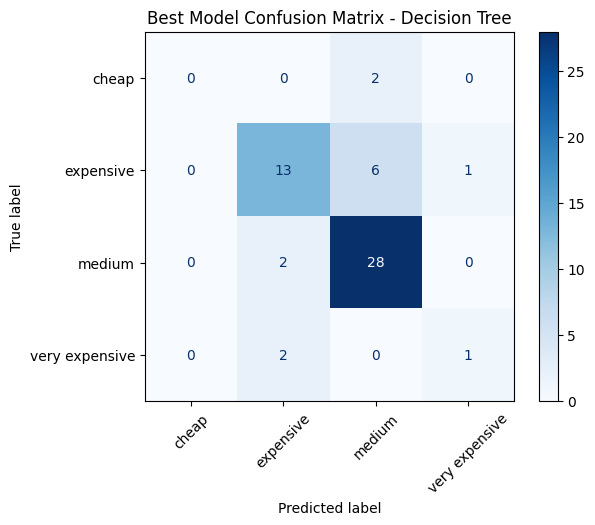

In [72]:
print("--- The Best Performance: Decision Tree ---")

best_test_acc = accuracy_score(y_test, dt_pred_unnorm)
best_test_pr = precision_score(y_test, dt_pred_unnorm, average='macro', zero_division=0)
best_test_rc = recall_score(y_test, dt_pred_unnorm, average='macro', zero_division=0)

print(f"Best Test Accuracy:  {best_test_acc:.4f}")
print(f"Best Test Precision: {best_test_pr:.4f}")
print(f"Best Test Recall:    {best_test_rc:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt_unnorm, display_labels=dt_grid_unnorm.classes_)
disp.plot(cmap='Blues')
plt.title("Best Model Confusion Matrix - Decision Tree")
plt.xticks(rotation=45)
plt.show()